In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/Intent-Classification-ML-Project

data  notebooks  README.md  requirements.txt  src


In [ ]:
# Step 1: Point Colab to your project folder in Drive
%cd /content/drive/MyDrive/Intent-Classification-ML-Project/

# See what's inside the project
!ls

# See what files are in the data/ folder
!ls data

/content/drive/MyDrive/Intent-Classification-ML-Project
data  notebooks  README.md  requirements.txt  src
rba-dataset.csv


Logging Dataset Loading

In [ ]:
import pandas as pd

# 🔁 Replace this with your actual CSV filename from the previous step
csv_path = "./data/rba-dataset.csv"

# Load a small sample first (e.g. 300k rows)
df_raw = pd.read_csv(csv_path, nrows=300000)

print("Shape:", df_raw.shape)

# See the column names
print("Columns:")
print(df_raw.columns.tolist())

# Look at first 5 rows as a table
df_raw.head()

Shape: (300000, 16)
Columns:
['index', 'Login Timestamp', 'User ID', 'Round-Trip Time [ms]', 'IP Address', 'Country', 'Region', 'City', 'ASN', 'User Agent String', 'Browser Name and Version', 'OS Name and Version', 'Device Type', 'Login Successful', 'Is Attack IP', 'Is Account Takeover']


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,0,2020-02-03 12:43:30.772,-4324475583306591935,NaN,10.0.65.171,NO,-,-,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Firefox 20.0.0.1618,iOS 13.4,mobile,False,False,False
1,1,2020-02-03 12:43:43.549,-4324475583306591935,NaN,194.87.207.6,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 46.0.2490,Android 4.1,mobile,False,False,False
2,2,2020-02-03 12:43:55.873,-3284137479262433373,NaN,81.167.144.58,NO,Vestland,Urangsvag,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
3,3,2020-02-03 12:43:56.180,-4324475583306591935,NaN,170.39.78.152,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile WebView 85.0.4183,Android 4.1,mobile,False,False,False
4,4,2020-02-03 12:43:59.396,-4618854071942621186,NaN,10.0.0.47,US,Virginia,Ashburn,398986,Mozilla/5.0 (Linux; U; Android 2.2) Build/NMA...,Chrome Mobile WebView 85.0.4183,Android 2.2,mobile,False,True,False


# EDA Steps

### Drop junk index col if present

In [ ]:
df_raw[df_raw["Region"].isna()]


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
517,517,2020-02-03 12:51:02.563,-91826601905320326,NaN,10.0.57.183,NO,NaN,Østfold,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
2753,2753,2020-02-03 13:18:21.293,1965376449542060573,NaN,10.0.116.243,NO,NaN,NaN,500001,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 69.0.3497.17.19,Mac OS X 10.14.6,desktop,True,False,False
3003,3003,2020-02-03 13:21:07.881,7045859536944212020,NaN,10.3.19.215,MW,NaN,NaN,507361,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 72.0.3626.105,Mac OS X 10.14.6,desktop,True,False,False
7217,7217,2020-02-03 14:10:02.835,-5946097014299712769,NaN,10.3.95.161,NO,NaN,Oppegard,500167,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_4...,Chrome 86.0.4240.375,Mac OS X 10.8.4,desktop,True,False,False
10066,10066,2020-02-03 14:43:07.735,8488946108544163258,NaN,10.0.117.83,NO,NaN,NaN,207464,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Chrome Mobile WebView 85.0.4183,iOS 13.4,mobile,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294485,294485,2020-02-07 10:00:54.396,-4324475583306591935,NaN,10.2.67.63,RO,NaN,NaN,500061,Mozilla/5.0 (Macintosh; Intel Mac OS X 11_6_3...,Chrome 80.0.3987.252.256,Mac OS X 11.6.3,desktop,False,False,False
295785,295785,2020-02-07 10:20:06.136,7045859536944212020,NaN,10.3.19.215,MW,NaN,NaN,507361,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 72.0.3626.105,Mac OS X 10.14.6,desktop,True,False,False
296555,296555,2020-02-07 10:30:45.643,-303816097656981991,NaN,10.0.65.224,NO,NaN,Bo,29695,Mozilla/5.0 (iPad; CPU OS 8_2 like Mac OS X) ...,Android 2.3.6,iOS 8.2,mobile,False,False,False
296628,296628,2020-02-07 10:31:44.635,-303816097656981991,NaN,10.0.65.224,NO,NaN,Bo,29695,Mozilla/5.0 (iPad; CPU OS 8_2 like Mac OS X) ...,Android 2.3.6,iOS 8.2,mobile,True,False,False


In [ ]:
df = df_raw.copy()
df.drop(columns=['index'],inplace=True,errors='ignore')

### Checking Missing Values

In [ ]:
# Missing value count per column (sorted)
missing_count = df_raw.isna().sum().sort_values(ascending=False)

# Show only columns that actually have missing values
missing_count[missing_count > 0]


,0
Round-Trip Time [ms],286788
Region,211
City,100
Device Type,14


### Handling Missing Values

In [ ]:
df = df_raw.copy()
df["Round-Trip Time [ms]"] = pd.to_numeric(
    df["Round-Trip Time [ms]"], errors="coerce"
)

df["Round-Trip Time [ms]"] = df["Round-Trip Time [ms]"].fillna(
    df["Round-Trip Time [ms]"].median()
)

In [ ]:
# df["region_was_missing"] = df["Region"].isna().astype(int)

In [ ]:
# string cols: fill + normalize (important for rule checks)
for col in ["Country", "Region", "City", "Device Type"]:
    df[col] = df[col].fillna("unknown").astype(str).str.strip().str.lower()

# optional safe-cast
df["ASN"] = df["ASN"].astype(str)


In [ ]:
df["Login Timestamp"] = pd.to_datetime(df["Login Timestamp"])
df = df.sort_values(["User ID", "Login Timestamp"]).reset_index(drop=True)

df["Login Timestamp"].min(), df["Login Timestamp"].max()

(Timestamp('2020-02-03 12:43:30.772000'),
 Timestamp('2020-02-07 11:17:17.158000'))

In [ ]:
# Normalize location + device
for col in ["Country", "Region", "City", "Device Type"]:
    df[col] = df[col].str.strip().str.lower()

# ASN as categorical
df["ASN"] = df["ASN"].astype(str)

# Simplify browser & OS
df["browser"] = df["Browser Name and Version"].str.extract(r"^([A-Za-z]+)")[0].str.lower()
df["os"] = df["OS Name and Version"].str.extract(r"^([A-Za-z]+)")[0].str.lower()

In [ ]:
df[["Browser Name and Version", "browser", "OS Name and Version", "os"]].head()

,Browser Name and Version,browser,OS Name and Version,os
0,Chrome 69.0.3497.17.19,chrome,Mac OS X 10.14.6,mac
1,Android 2.3.3.2672,android,iOS 7.1,ios
2,Android 2.3.3.2672,android,iOS 7.1,ios
3,Chrome Mobile 81.0.4044.2033,chrome,iOS 13.4,ios
4,Opera Mobile 52.1.2254,opera,Android 13.0,android


In [ ]:
# df[df["browser"].isna()]

There no Empty Rows now for sample 20,000

In [ ]:
df.isna().sum()
[df.isna().sum() > 0]

[index                       False
 Login Timestamp             False
 User ID                     False
 Round-Trip Time [ms]        False
 IP Address                  False
 Country                     False
 Region                      False
 City                        False
 ASN                         False
 User Agent String           False
 Browser Name and Version    False
 OS Name and Version         False
 Device Type                 False
 Login Successful            False
 Is Attack IP                False
 Is Account Takeover         False
 browser                      True
 os                           True
 dtype: bool]

In [ ]:
# string cols: fill + normalize (important for rule checks)
for col in ["browser"]:
    df[col] = df[col].fillna("unknown").astype(str).str.strip().str.lower()

In [ ]:
df.isna().sum()
[df.isna().sum() > 0]

[index                       False
 Login Timestamp             False
 User ID                     False
 Round-Trip Time [ms]        False
 IP Address                  False
 Country                     False
 Region                      False
 City                        False
 ASN                         False
 User Agent String           False
 Browser Name and Version    False
 OS Name and Version         False
 Device Type                 False
 Login Successful            False
 Is Attack IP                False
 Is Account Takeover         False
 browser                     False
 os                           True
 dtype: bool]

# 2. Data Quality

Shape + Columns + Dtypes

In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

Shape: (300000, 18)

Columns:
['index', 'Login Timestamp', 'User ID', 'Round-Trip Time [ms]', 'IP Address', 'Country', 'Region', 'City', 'ASN', 'User Agent String', 'Browser Name and Version', 'OS Name and Version', 'Device Type', 'Login Successful', 'Is Attack IP', 'Is Account Takeover', 'browser', 'os']

Dtypes:
index                                int64
Login Timestamp             datetime64[ns]
User ID                              int64
Round-Trip Time [ms]               float64
IP Address                          object
Country                             object
Region                              object
City                                object
ASN                                 object
User Agent String                   object
Browser Name and Version            object
OS Name and Version                 object
Device Type                         object
Login Successful                      bool
Is Attack IP                          bool
Is Account Takeover                   b

Duplicate Checks (VERY small step)

We first check for full-row duplicates to identify data ingestion errors. We then check for logical duplicates using key identifiers such as user, timestamp, and IP, which represent a single login event. This helps avoid double-counting login attempts that differ only in metadata.

	•	User ID → who
	•	Login Timestamp → when
	•	IP Address → from where

In [ ]:
# Full row duplicates
print("Duplicate full rows:", df.duplicated().sum())

# Duplicate login events (same user, same time, same IP)
key_cols = ["User ID", "Login Timestamp", "IP Address"]
print(
    "Duplicate key events:",
    df.duplicated(subset=key_cols).sum()
)

Duplicate full rows: 0
Duplicate key events: 0


Final Missing Values Check

In [ ]:
missing = df.isna().sum()
missing = missing[missing > 0]

print("Columns with missing values:")
print(missing)

print("\nMissing percentage:")
print((missing / len(df) * 100).round(3))

Columns with missing values:
os    14
dtype: int64

Missing percentage:
os    0.005
dtype: float64


# 3. Pattern Check

### Label distribution + base rate

In your 20,000-row sample, there are zero Account Takeover events.
So if we keep using Is Account Takeover right now:
	•	every chart will show 0 risk
	•	no “risk concentration” analysis is possible
	•	and later, a model can’t learn anything (no positive class)

So we are continue using Is Attack IP  - result is Positive rate: ~9.7%

In [ ]:
label = "Is Attack IP"  # preferred
print("Using label:", label)

print("\nValue counts:")
print(df[label].value_counts())

print("\nPositive rate:")
print(df[label].mean())

Using label: Is Attack IP

Value counts:
Is Attack IP
False    272348
True      27652
Name: count, dtype: int64

Positive rate:
0.09217333333333333


Risk by Hour of Day


```
# Check whether risky logins cluster at certain hours.
```



hour
0     0.073578
1     0.146824
2     0.195648
3     0.191407
4     0.179715
5     0.160712
6     0.122327
7     0.104156
8     0.086157
9     0.085086
10    0.084813
11    0.086145
12    0.087766
13    0.091829
14    0.097852
15    0.106678
16    0.102129
17    0.083518
18    0.065542
19    0.057831
20    0.046403
21    0.034985
22    0.038179
23    0.058731
Name: Is Attack IP, dtype: float64


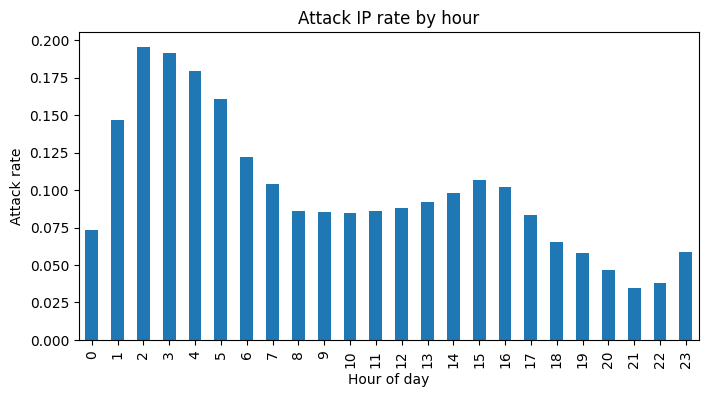

DA shows that attack IPs are significantly more likely during off-hours, so we include time-of-day as both a rule signal and an ML feature.


In [ ]:
# We are using label=Is Attack Ip from above section

df["hour"] = df["Login Timestamp"].dt.hour

hour_rate = df.groupby("hour")[label].mean()

print(hour_rate)

hour_rate.plot(kind="bar", figsize=(8,4))
plt.title("Attack IP rate by hour")
plt.xlabel("Hour of day")
plt.ylabel("Attack rate")
plt.show()


print("DA shows that attack IPs are significantly more likely during off-hours, so we include time-of-day as both a rule signal and an ML feature.")

We can use this for baseline ---

---

> Note: is_off_hours = 1 if hour ∈ [1, 6] else 0





Risk by Day of Week

dayofweek
0    0.078511
1    0.096087
2    0.094801
3    0.086753
4    0.110610
Name: Is Attack IP, dtype: float64


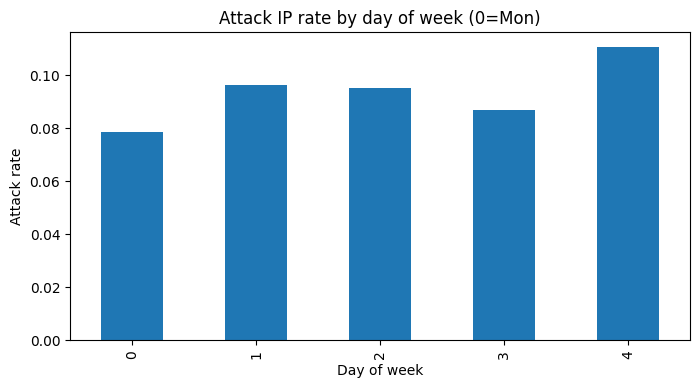

In [ ]:
# We are using label=Is Attack Ip from above section

df["dayofweek"] = df["Login Timestamp"].dt.dayofweek  # 0=Mon, 6=Sun

dow_rate = df.groupby("dayofweek")[label].mean()
print(dow_rate)

dow_rate.plot(kind="bar", figsize=(8,4))
plt.title("Attack IP rate by day of week (0=Mon)")
plt.xlabel("Day of week")
plt.ylabel("Attack rate")
plt.show()

Mention this later in report

> “Attack IPs appear slightly more frequent on some weekdays (e.g., day 4), but the variation is modest compared to the stronger off-hours pattern seen between 1–6 AM.”



```
# This is why we choose 'hour of day' rather than 'day of week'
```





# 4. User Profiling

Per-User Statistics



```
# 	•	Most users:
	•	events: 1–3 logins
	•	unique_ips: 1
	•	unique_devices: 1
	•	A few users:
	•	huge numbers of events and IPs (crazy outliers)
```

Conclusion: Our model will classify login events
e.g. “This login at 02:13 from IP X with device Y – risky or not?”

We’re not classifying users as “good/bad”. The user-level stats are just to understand behavior, not the final thing we feed directly to the model.


In [ ]:
user_stats = df.groupby("User ID").agg(
    events=("Login Timestamp", "count"),
    success_rate=("Login Successful", "mean"),
    unique_ips=("IP Address", "nunique"),
    unique_cities=("City", "nunique"),
    unique_devices=("Device Type", "nunique"),
    attack_rate=("Is Attack IP", "mean"),
    median_rtt=("Round-Trip Time [ms]", "median"),
)

summary = user_stats.describe(percentiles=[0.5, 0.75, 0.9, 0.95]).T
print(summary)

                   count        mean         std   min    50%    75%    90%  \
events          114804.0    2.613149  312.820465   1.0    1.0    2.0    3.0   
success_rate    114804.0    0.771322    0.384358   0.0    1.0    1.0    1.0   
unique_ips      114804.0    1.535548  142.025424   1.0    1.0    1.0    1.0   
unique_cities   114804.0    1.106277   12.251682   1.0    1.0    1.0    1.0   
unique_devices  114804.0    1.049885    0.224329   1.0    1.0    1.0    1.0   
attack_rate     114804.0    0.070753    0.251237   0.0    0.0    0.0    0.0   
median_rtt      114804.0  545.919615  143.589861  11.0  541.0  541.0  541.0   

                  95%       max  
events            4.0  105992.0  
success_rate      1.0       1.0  
unique_ips        2.0   48123.0  
unique_cities     2.0    4151.0  
unique_devices    1.0       5.0  
attack_rate       1.0       1.0  
median_rtt      541.0   23290.0  


Checking Visuals of Unique IP Unique Device

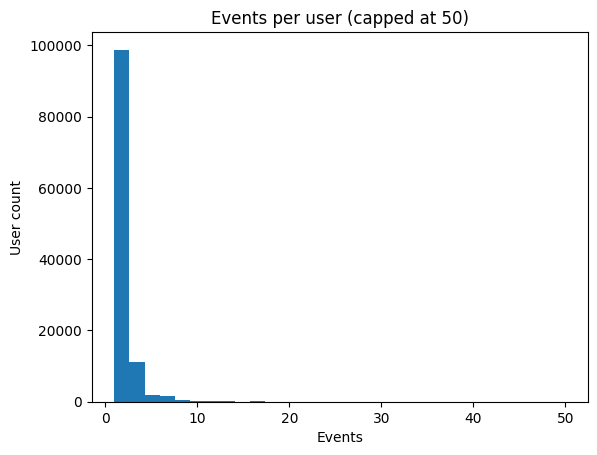

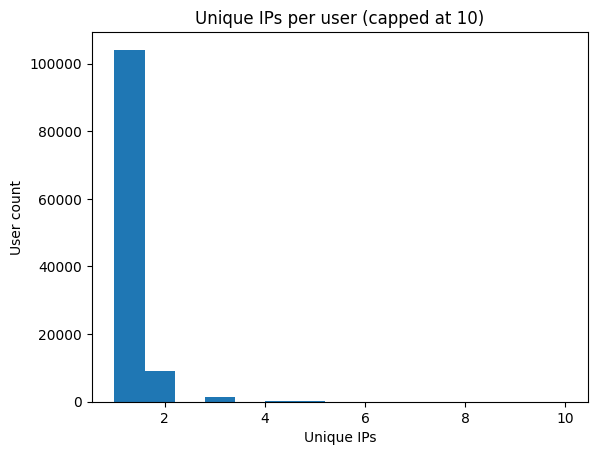

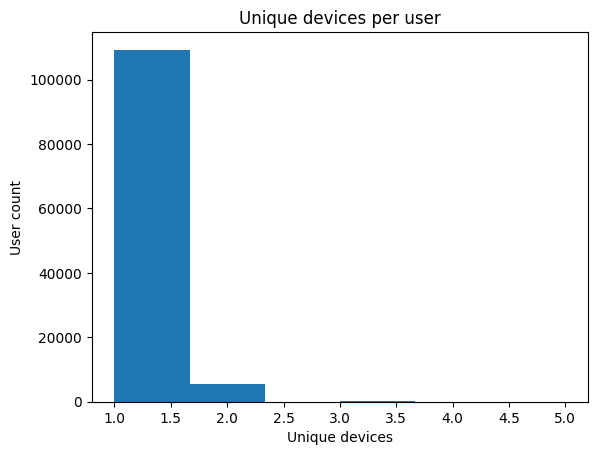

In [ ]:
# Cap very large values just for plotting so histograms are readable
events_capped = user_stats["events"].clip(upper=50)
ips_capped = user_stats["unique_ips"].clip(upper=10)
devices = user_stats["unique_devices"]

plt.hist(events_capped, bins=30)
plt.title("Events per user (capped at 50)")
plt.xlabel("Events")
plt.ylabel("User count")
plt.show()

plt.hist(ips_capped, bins=15)
plt.title("Unique IPs per user (capped at 10)")
plt.xlabel("Unique IPs")
plt.ylabel("User count")
plt.show()

plt.hist(devices, bins=6)
plt.title("Unique devices per user")
plt.xlabel("Unique devices")
plt.ylabel("User count")
plt.show()

Risk for new vs seen Device & IP

Conclusion:

```
# So in this dataset:
	•	Logins from devices/IPs that have been seen before for that user (flag = 0)
→ actually have higher attack IP rate
	•	First-time device/IP for that user (flag = 1)
→ lower attack IP rate

This is the opposite of the naive “new device = bad” story and tells us something about how this dataset behaves.


```



In [ ]:
# Make sure data is sorted by user + time
df = df.sort_values(["User ID", "Login Timestamp"]).reset_index(drop=True)

# 1) New device for this user?
df["is_new_device_for_user"] = (
    df.groupby("User ID")["Device Type"]
      .apply(lambda s: (~s.duplicated()).astype(int))  # 1 = first time this device seen for this user
      .reset_index(level=0, drop=True)
)

# 2) New IP for this user?
df["is_new_ip_for_user"] = (
    df.groupby("User ID")["IP Address"]
      .apply(lambda s: (~s.duplicated()).astype(int))  # 1 = first time this IP seen for this user
      .reset_index(level=0, drop=True)
)

Attack rate: new vs seen device

Attack rate by new/seen device:
is_new_device_for_user
0    0.108314
1    0.068140
Name: Is Attack IP, dtype: float64

Counts by new/seen device:
is_new_device_for_user
0    179469
1    120531
Name: count, dtype: int64


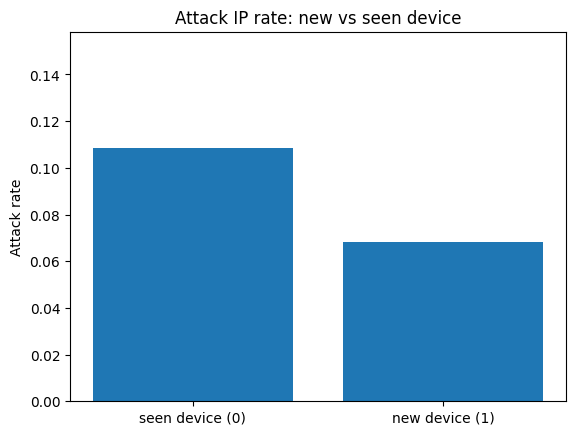

In [ ]:
import matplotlib.pyplot as plt

# Make a small summary table for device
device_risk = df.groupby("is_new_device_for_user")["Is Attack IP"].mean()
device_counts = df["is_new_device_for_user"].value_counts()

print("Attack rate by new/seen device:")
print(device_risk)
print("\nCounts by new/seen device:")
print(device_counts)

# Map 0/1 to labels for the x-axis
device_labels = ["seen device (0)", "new device (1)"]
device_rates = [device_risk[0], device_risk[1]]

plt.bar(device_labels, device_rates)
plt.title("Attack IP rate: new vs seen device")
plt.ylabel("Attack rate")
plt.ylim(0, max(device_rates) + 0.05)
plt.show()

Attack rate: new vs seen IP

Attack rate by new/seen IP:
is_new_ip_for_user
0    0.121798
1    0.071384
Name: Is Attack IP, dtype: float64

Counts by new/seen IP:
is_new_ip_for_user
1    176287
0    123713
Name: count, dtype: int64


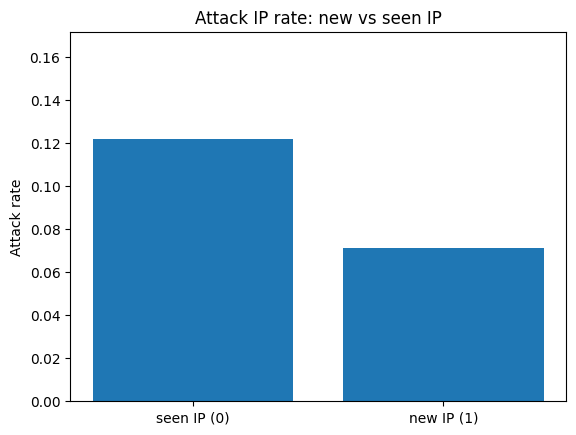

In [ ]:
# Summary for IP
ip_risk = df.groupby("is_new_ip_for_user")["Is Attack IP"].mean()
ip_counts = df["is_new_ip_for_user"].value_counts()

print("Attack rate by new/seen IP:")
print(ip_risk)
print("\nCounts by new/seen IP:")
print(ip_counts)

ip_labels = ["seen IP (0)", "new IP (1)"]
ip_rates = [ip_risk[0], ip_risk[1]]

plt.bar(ip_labels, ip_rates)
plt.title("Attack IP rate: new vs seen IP")
plt.ylabel("Attack rate")
plt.ylim(0, max(ip_rates) + 0.05)
plt.show()

Risk Concentration by Category

In [ ]:
def lift_table(data, col, label_col, min_count=100, top=10):
    tmp = (
        data.groupby(col)[label_col]
        .agg(count="count", pos_rate="mean")
        .query("count >= @min_count")     # keep only values with enough rows
        .sort_values("pos_rate", ascending=False)
    )
    return tmp.head(top)

device_lift = lift_table(df, "Device Type", label)
country_lift = lift_table(df, "Country", label)
region_lift = lift_table(df, "Region", label)
city_lift = lift_table(df, "City", label)

print("Top risky Device Types:")
print(device_lift)

print("\nTop risky Countries:")
print(country_lift)

print("\nTop risky Countries:")
print(region_lift)

print("\nTop risky Countries:")
print(city_lift)

Top risky Device Types:
              count  pos_rate
Device Type                  
bot             234  0.773504
unknown         167  0.323353
mobile       212206  0.117080
desktop       78276  0.029779
tablet         9117  0.026434

Top risky Countries:
         count  pos_rate
Country                 
ru         313  0.549521
cl         442  0.533937
ro        1733  0.466821
iq         113  0.362832
us       64532  0.310187
vn         225  0.288889
pk         203  0.266010
ph         474  0.175105
tr        1660  0.137952
id        4292  0.129077

Top risky Countries:
            count  pos_rate
Region                     
new jersey    133  0.864662
illinois      139  0.712230
virginia      118  0.703390
moscow        135  0.674074
bucuresti     797  0.608532
washington    164  0.603659
california    200  0.585000
new york      231  0.393939
silesia      1572  0.341603
colorado      157  0.331210

Top risky Countries:
               count  pos_rate
City                          
cz

Conclusion:

Device
```
	•	bot: ~77% of events from “bot” device type are attack IPs
→ basically “if device_type = bot, it’s almost always malicious”.
	•	unknown: ~32% attack rate
→ still very high risk compared to normal users.
	•	mobile: ~11.7% attack rate
→ slightly above the overall dataset average (~9.7%), so mildly riskier.
	•	desktop / tablet: ~2.6–3% attack rate
→ clearly lower risk segment.
```
From EDA, we observed that logins labeled as ‘bot’ or ‘unknown’ device types have much higher attack IP rates, whereas desktop and tablet devices show much lower risk. This supports including device type as both a rule signal and a model feature.

Country


```
# In the provided RBA dataset, certain source countries show significantly higher attack IP rates. This likely reflects how the dataset was constructed (e.g., simulated attack traffic originating from specific regions) rather than real-world population risk. We therefore treat country as a contextual risk feature, but interpret it cautiously.”
```




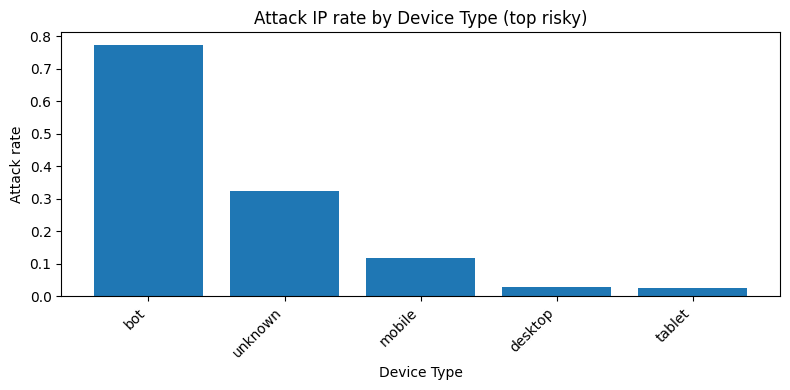

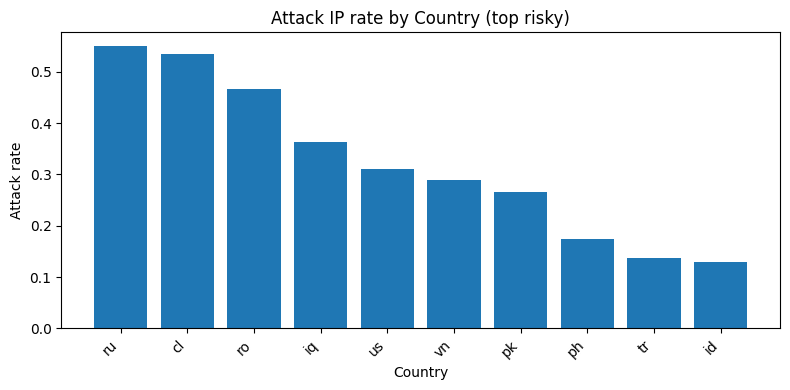

In [ ]:
import matplotlib.pyplot as plt

# Device Type plot
if not device_lift.empty:
    plt.figure(figsize=(8,4))
    plt.bar(device_lift.index.astype(str), device_lift["pos_rate"])
    plt.title("Attack IP rate by Device Type (top risky)")
    plt.xlabel("Device Type")
    plt.ylabel("Attack rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Country plot
if not country_lift.empty:
    plt.figure(figsize=(8,4))
    plt.bar(country_lift.index.astype(str), country_lift["pos_rate"])
    plt.title("Attack IP rate by Country (top risky)")
    plt.xlabel("Country")
    plt.ylabel("Attack rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## EDA Summary – RBA Dataset (300k Sample)

### 1. Label Distribution
- Using `Is Attack IP` as the main label for analysis.
- In the 300k sample, ~**9–10%** of events are labeled as attack IPs.
- `Is Account Takeover` is extremely rare in the smaller sample (all zeros), so not used for early EDA.

---

### 2. Time-Based Patterns
- **Hour of day:** Clear off-hours spike in attack rate between **1 AM–6 AM**, with peaks around **2–5 AM**.
- **Day of week (0–4 / Mon–Fri):** Attack rate varies slightly (~8–11%), but differences are small.
- → **Time-of-day is a stronger risk signal than day-of-week** in this dataset.

---

### 3. User Behavior Profile
- **Users:** 114k+ unique users in the 300k slice.
- **Activity per user:**
  - Median events per user ≈ **1**
  - 90th percentile ≈ **3**, 95th ≈ **4**
- **Stability:**
  - Most users use **1 IP** and **1 device**.
  - A few extreme outliers have **very high event and IP counts**, likely synthetic or attacker-style accounts.
- Most users have high login success rates and never touch attack IPs; a small subset shows concentrated attack activity.

---

### 4. New vs Seen Device/IP
- Flags:
  - `is_new_device_for_user` = 1 on first time user uses a given device type.
  - `is_new_ip_for_user` = 1 on first time user uses a given IP.
- In this dataset:
  - **Seen devices/IPs (flag = 0)** have *higher* attack IP rates than first-time devices/IPs.
- Interpretation:
  - Suggests **attacker persistence** (reuse of the same IP/device) rather than only one-off random new IPs.
  - “New = suspicious” is **not always true** here; newness should be one signal among several.

---

### 5. Device Type Risk Patterns
- Attack IP rate by `Device Type` (with min count threshold):
  - `bot` ≈ **77%**
  - `unknown` ≈ **32%**
  - `mobile` ≈ **11.7%**
  - `desktop` / `tablet` ≈ **2–3%**
- → `bot` and `unknown` behave like high-risk device categories; desktop/tablet appear relatively safer.

---

### 6. Country-Level Patterns (Contextual Only)
- Some source countries in the dataset show **elevated attack IP rates** (e.g., `ru`, `cl`, `ro`, `iq`, `us`).
- This likely reflects **dataset construction / simulated attack traffic**, not real-world population behavior.
- Country is treated as a **contextual network feature**, not a user-level judgment.

---

### 7. Takeaways for Next Steps
- Clear, interpretable patterns:
  - Off-hours logins, certain device types, and some origin countries correlate strongly with attack IPs.
  - Most users are stable (single IP, single device), while attackers show outlier or persistent patterns.
- These insights will guide:
  - Design of a **rule-based baseline** (time, device type, simple context).
  - Later **feature engineering** for intent-based ML (behavior + context + history).

Failed logins are more strongly associated with attack IPs than successful logins, but a non-trivial number of successful logins also come from attack IPs. This supports using failure patterns as an important risk feature, while not assuming that all attacks necessarily fail.

In [521]:

print("Login Successful value counts:")
print(df["Login Successful"].value_counts())

print("\nAttack IP rate by login outcome:")
print(df.groupby("Login Successful")[label].mean())

print("\nCrosstab of Login Successful vs Attack IP:")
print(pd.crosstab(df["Login Successful"], df[label]))


Login Successful value counts:
Login Successful
False    153257
True     146743
Name: count, dtype: int64

Attack IP rate by login outcome:
Login Successful
False    0.122278
True     0.060732
Name: Is Attack IP, dtype: float64

Crosstab of Login Successful vs Attack IP:
Is Attack IP       False  True 
Login Successful               
False             134517  18740
True              137831   8912


Logins Per Minute + Attack Rate Over Time

In [ ]:
df["Is Attack IP"].value_counts().plot(kind="bar")
plt.title("Attack vs Non-Attack")
plt.xlabel("Is Attack IP")
plt.ylabel("Count")
plt.show()

logins_per_min = (
    df.groupby(df["Login Timestamp"].dt.floor("T"))
      .size()
)

logins_per_min.plot(figsize=(8,4))
plt.title("Logins Per Minute")
plt.xlabel("Time")
plt.ylabel("Count")
plt.show()

df["Device Type"].value_counts().plot(kind="bar", figsize=(5,4))
plt.title("Login Device Types")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.show()

df["browser"].value_counts().head(10).plot(kind="bar", figsize=(6,4))
plt.title("Top Browsers Used")
plt.xlabel("Browser")
plt.ylabel("Count")
plt.show()

ip_counts = df.groupby("User ID")["IP Address"].nunique()

plt.hist(ip_counts, bins=30)
plt.title("Unique IPs per User")
plt.xlabel("Number of IPs")
plt.ylabel("Users")
plt.show()

device_per_user = df.groupby("User ID")["Device Type"].nunique()

plt.hist(device_per_user, bins=10)
plt.title("Device Diversity per User")
plt.xlabel("Unique Devices per User")
plt.ylabel("User Count")
plt.show()

#Derived Features


In [ ]:
#New location flag
df["location"] = df["Country"] + "|" + df["Region"] + "|" + df["City"]

#A location is valid only if Region and City are known.
df["valid_location"] = ~(
    df["Region"].isin(["-", "Unknown"]) |
    df["City"].isin(["-", "Unknown"])
)

#Detect raw location per user
df["new_location_flag_raw"] = (
    df.groupby("User ID")["location"]
      .transform(lambda x: x != x.shift())
).astype(int)

#Remov
df["new_location_flag_clean"] = df["new_location_flag_raw"]
df.loc[
    df.groupby("User ID").head(1).index,
    "new_location_flag_clean"
] = 0

